In [15]:
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd 

In [16]:
cancer = load_breast_cancer(as_frame = True)
df = cancer.frame
print(df.head(3))

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38           122.8     1001.0          0.11840   
1        20.57         17.77           132.9     1326.0          0.08474   
2        19.69         21.25           130.0     1203.0          0.10960   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0                 0.07871  ...          17.33            184.6      2019.0   
1                 0.05667  ...          23.41            158.8      1956.0   
2                 0.05999  ...          25.53            152.5      1709.0   

   worst smoothness  worst compactness  worst concavity  worst concave points  \


In [17]:
X = cancer.data
y = cancer.target

In [18]:
x_train,x_test,y_train,y_test = train_test_split(cancer.data,cancer.target, test_size=0.2, random_state=22)

x_train.shape,x_test.shape,y_train.shape,y_test.shape

((455, 30), (114, 30), (455,), (114,))

In [19]:
tree = DecisionTreeClassifier(random_state=32)
tree.fit(x_train,y_train)
y_pred = tree.predict(x_test)
print(accuracy_score(y_test,y_pred))

0.9385964912280702


In [20]:
print(tree.get_depth())

7


In [21]:
x_axis_idx = 0  # 'mean radius'
y_axis_idx = 1  # 'mean texture'

# 4. Automate the filler dictionaries for the other 28 features
# Features not on the plot must be held constant at their mean values
filler_values = {}
filler_ranges = {}

for i in range(X.shape[1]):
    if i not in [x_axis_idx, y_axis_idx]:
        # Hold feature constant at its mean value
        filler_values[i] = X.iloc[:, i].mean()
        # Set a search range tolerance so points close to the slice appear
        filler_ranges[i] = X.iloc[:, i].std() * 0.5  

d:\Coding\deep-learning-pytorch\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


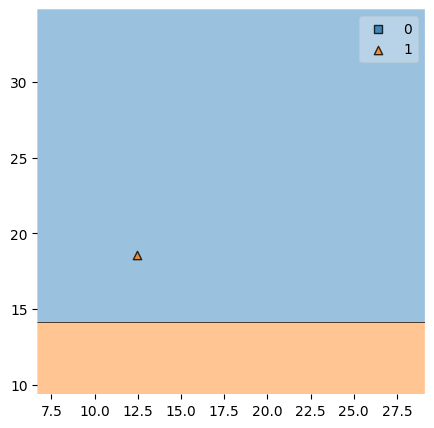

In [22]:
from mlxtend.plotting import plot_decision_regions
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(5,5))
plot_decision_regions(x_train.to_numpy(),y_train.to_numpy(),tree,filler_feature_ranges=filler_ranges, filler_feature_values= filler_values)
plt.show()

d:\Coding\deep-learning-pytorch\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


<Axes: >

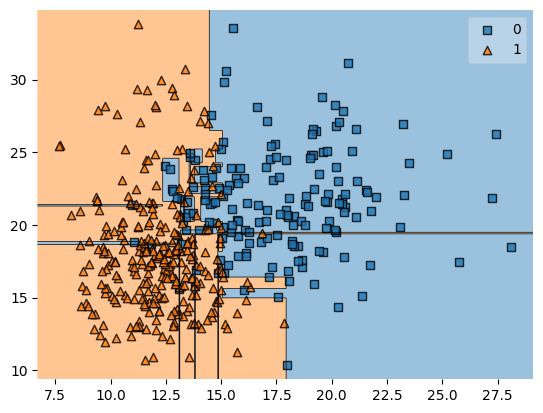

In [26]:
tree2d = DecisionTreeClassifier(random_state=742)
tree2d.fit(x_train.iloc[:, [x_axis_idx, y_axis_idx]], y_train)
plot_decision_regions(x_train.iloc[:, [x_axis_idx, y_axis_idx]].to_numpy(), y_train.to_numpy(), tree2d)

#Using filler values with a 30-feature model works too, but the boundary you see is just a slice

In [27]:
pred_TREE1 = tree.predict(x_test)
print(accuracy_score(y_test,pred_TREE1))

0.9385964912280702


In [28]:
pred_TREE2 = tree.predict(x_test)
print(accuracy_score(y_test,pred_TREE2))

0.9385964912280702


In [50]:
bag = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42), n_estimators=500, max_samples=0.7,oob_score=True )

bag.fit(x_train,y_train)
pred_bag = bag.predict(x_test)
print(accuracy_score(pred_bag,y_test))

0.9649122807017544


In [51]:
bag.oob_score_

0.967032967032967